# Data Preprocessing Tools

## Importing the libraries



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests
from io import BytesIO
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, MiniBatchKMeans
from sklearn.metrics import silhouette_score
import gc  #For garbage collection to free memory

## Importing the dataset



In [2]:
#Raw GitHub URL for the Excel file
url = "https://raw.githubusercontent.com/RihalMahmood/CSSE445-Assignments/main/Datasets/LOL%20RAW%20DATA.xlsx"

try:
    #Fetch the Excel file content
    response = requests.get(url)
    response.raise_for_status()  # Check for request errors

    #Load the Excel file into a pandas DataFrame
    excel_data = BytesIO(response.content)
    df = pd.read_excel(excel_data, engine='openpyxl')  # Use 'xlrd' for .xls files

    #Display the first few rows
    print("Dataset loaded successfully!")
    print(df.head())

except requests.exceptions.RequestException as e:
    print(f"Error fetching the dataset: {e}")
except pd.errors.ParserError as e:
    print(f"Error parsing the Excel file: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Dataset loaded successfully!
   CASE        TIER    LP  LEVEL   WINLOSEPER  AVSCORE LASTWINLOSE  LASTLOGIN  \
0     1  challenger  1311    421   150W93L62%    3.894    8W12L40% 2023-03-19   
1     2  challenger  1300    414    97W46L68%    3.603    13W7L65% 2023-03-21   
2     3  challenger  1281    534  150W105L59%    3.977    16W4L80% 2023-03-21   
3     4  challenger  1252    599  171W127L57%    1.670   10W10L50% 2023-03-21   
4     5  challenger  1243    441  278W232L55%    3.523    8W12L40% 2023-03-20   

   NO TEAM PARTICIPANTS  NO TEAM GAMES  ... START SEASON   SEASON TIER  \
0                    10             22  ...     Season 6     DIAMOND 5   
1                    10             28  ...     Season 7     DIAMOND 2   
2                    10             28  ...     Season 8     DIAMOND 2   
3                    10             31  ...     Season 8  CHALLENGER 1   
4                    10             33  ...     Season 8     DIAMOND 1   

   LAST SEASON     LAST TIER  TOTAL HOU

This dataset was collected to analyze and predict gamer churn in League of Legends (LOL) during Season 13. Data was obtained from the LOL Korea server via Riot Games' API and web scraping tools such as Selenium and Pandas. The raw dataset consists of 295,486 cases.

##Checking missing values

In [3]:
print(df.isnull().sum())

CASE                      0
TIER                      0
LP                        0
LEVEL                     0
WINLOSEPER                0
AVSCORE                   0
LASTWINLOSE               0
LASTLOGIN                 0
NO TEAM PARTICIPANTS      0
NO TEAM GAMES             0
TEAM WINRATE              0
TEAM WIN                  0
TEAM LOSE                 0
WIN DUMMY                 0
LOSING STREAK             0
NO CHAMPIONS PLAYED       0
T_POSITION                0
P_NO POSITION             0
START SEASON            478
SEASON TIER             478
LAST SEASON             478
LAST TIER               478
TOTAL HOUR                0
TOTAL MIN                 0
TOTAL DAY                 0
TOTAL MATCH               0
OBS DATE                  0
DATE                      0
dtype: int64


## Taking care of missing data


### Dropping Rows

In [4]:
#Removing rows having missing values in column 19
df_cleaned = df.dropna(subset=[df.columns[18]])

Column 19-22 **(Index[18-21])** have values missing for the exact same rows. So removing rows in which values are missing for column 19 will also remove the rows in which values are missing for columns 20-22.

In [5]:
print(df_cleaned.isnull().sum())

CASE                    0
TIER                    0
LP                      0
LEVEL                   0
WINLOSEPER              0
AVSCORE                 0
LASTWINLOSE             0
LASTLOGIN               0
NO TEAM PARTICIPANTS    0
NO TEAM GAMES           0
TEAM WINRATE            0
TEAM WIN                0
TEAM LOSE               0
WIN DUMMY               0
LOSING STREAK           0
NO CHAMPIONS PLAYED     0
T_POSITION              0
P_NO POSITION           0
START SEASON            0
SEASON TIER             0
LAST SEASON             0
LAST TIER               0
TOTAL HOUR              0
TOTAL MIN               0
TOTAL DAY               0
TOTAL MATCH             0
OBS DATE                0
DATE                    0
dtype: int64


No more missing values left in the dataset.

### Dropping Columns

In [6]:
df_cleaned = df_cleaned.drop(columns=['CASE', 'WINLOSEPER', 'LASTLOGIN', 'TEAM WINRATE', 'LAST SEASON', 'OBS DATE', 'DATE'])

Removed column **'CASE'** as it holds the serial number of players.

Removed column **'WINLOSEPER'**, as an existing feature **'AVSCORE'** holds its percentage value.

Removed column **'TEAM WINRATE'**, as two existing features **'TEAM WIN', 'TEAM LOSE'** already describes the number of matches won and lost by that player.         

Removed columns **'LAST SEASON', 'DATE'** as these have only a single value across the column.

In [7]:
#Define the mapping for T_POSITION column
position_mapping = {
    '정글': 'Jungle',
    '서폿': 'Support',
    '탑': 'Top',
    '원딜': 'Carry',
    '미드': 'Mid'
}

#Replace values in the T_POSITION column (index 12)
df_cleaned["T_POSITION"] = df_cleaned["T_POSITION"].replace(position_mapping)

#Display the first few rows to verify changes
print(df_cleaned["T_POSITION"].unique())

['Jungle' 'Support' 'Top' 'Carry' 'Mid']


The column **'T_POSITION'** has values written in Korean. We mapped those values to it's equivalent English translation.

In [8]:
print(df_cleaned.isnull().sum())

TIER                    0
LP                      0
LEVEL                   0
AVSCORE                 0
LASTWINLOSE             0
NO TEAM PARTICIPANTS    0
NO TEAM GAMES           0
TEAM WIN                0
TEAM LOSE               0
WIN DUMMY               0
LOSING STREAK           0
NO CHAMPIONS PLAYED     0
T_POSITION              0
P_NO POSITION           0
START SEASON            0
SEASON TIER             0
LAST TIER               0
TOTAL HOUR              0
TOTAL MIN               0
TOTAL DAY               0
TOTAL MATCH             0
dtype: int64


In [9]:
df_cleaned.head()

,TIER,LP,LEVEL,AVSCORE,LASTWINLOSE,NO TEAM PARTICIPANTS,NO TEAM GAMES,TEAM WIN,TEAM LOSE,WIN DUMMY,...,NO CHAMPIONS PLAYED,T_POSITION,P_NO POSITION,START SEASON,SEASON TIER,LAST TIER,TOTAL HOUR,TOTAL MIN,TOTAL DAY,TOTAL MATCH
0,challenger,1311,421,3.894,8W12L40%,10,22,7,15,O,...,44,Jungle,2,Season 6,DIAMOND 5,CHALLENGER 1,16936,282,12,618
1,challenger,1300,414,3.603,13W7L65%,10,28,16,12,O,...,35,Jungle,5,Season 7,DIAMOND 2,CHALLENGER 1,139326,2322,97,5178
2,challenger,1281,534,3.977,16W4L80%,10,28,21,7,X,...,33,Support,2,Season 8,DIAMOND 2,CHALLENGER 1,103927,1732,72,3960
3,challenger,1252,599,1.670,10W10L50%,10,31,16,15,O,...,5,Top,3,Season 8,CHALLENGER 1,CHALLENGER 1,219813,3664,153,8285
4,challenger,1243,441,3.523,8W12L40%,10,33,11,22,O,...,25,Support,1,Season 8,DIAMOND 1,CHALLENGER 1,166092,2768,115,6063


First 5 rows of the updated dataset

## Encoding categorical data


Checking which columns have Numerical and Categorical data.

In [10]:
#Get unique values from all columns
i = 0
for column in df_cleaned.columns:
    unique_values = df_cleaned[column].unique()
    print(f"Unique values in column '{column}' {i}: {unique_values}")
    i += 1

Unique values in column 'TIER' 0: ['challenger' 'grandmaster' 'master' 'diamond 1' 'diamond 2' 'diamond 3'
 'diamond 4' 'platinum 1' 'platinum 2' 'platinum 3' 'platinum 4' 'gold 1'
 'gold 2']
Unique values in column 'LP' 1: [1311 1300 1281 1252 1243 1238 1209 1138 1136 1131 1115 1110 1081 1073
 1067 1057 1043 1040 1029 1022 1018 1010 1007 1006  993  989  987  986
  984  982  965  963  962  961  958  930  923  921  919  916  911  885
  884  869  865  864  859  858  857  855  852  842  836  834  826  823
  817  815  812  810  804  801  799  798  796  795  792  789  788  787
  784  783  781  777  773  770  769  765  762  761  757  753  750  747
  746  742  741  740  739  738  734  732  727  725  723  722  721  719
  718  716  715  714  712  711  708  705  703  701  699  696  691  689
  688  687  685  684  682  681  679  677  676  673  671  669  668  664
  661  660  659  655  653  652  651  646  640  638  636  634  633  631
  629  624  622  619  618  616  615  613  612  611  610  609  608 

### Feature Engineering

In [11]:
#Feature Engineering for LASTWINLOSE
#Extract wins, losses, and win percentage from LASTWINLOSE (e.g., '8W12L40%')
def parse_lastwinlose(row):
    try:
        wins = int(row.split('W')[0])  # Extract number before 'W'
        losses = int(row.split('W')[1].split('L')[0])  # Extract number between 'W' and 'L'
        win_pct = float(row.split('L')[1].replace('%', '')) / 100  # Extract percentage
        return pd.Series([wins, losses, win_pct])
    except:
        return pd.Series([0, 0, 0.0])  # Handle any parsing errors

#Apply parsing to create new columns
df_cleaned[['LAST_WINS', 'LAST_LOSSES', 'LAST_WIN_PCT']] = df_cleaned['LASTWINLOSE'].apply(parse_lastwinlose)

#Drop LASTWINLOSE as it's now represented by new columns
df_cleaned = df_cleaned.drop(columns=['LASTWINLOSE'])

Feature Engineering for LASTWINLOSE: This column (e.g., '8W12L40%') contains win-loss records and percentages. Instead of encoding it directly, we can extract numeric features (e.g., wins, losses, win percentage) to avoid high dimensionality from one-hot encoding many unique values.

### Label Encoding

In [12]:
#Defining categorical and numeric columns
categorical_cols = ['TIER', 'T_POSITION', 'P_NO POSITION', 'START SEASON', 'SEASON TIER', 'LAST TIER', 'WIN DUMMY']
numeric_cols = ['LP', 'LEVEL', 'AVSCORE', 'NO TEAM PARTICIPANTS', 'NO TEAM GAMES',
                'TEAM WIN', 'TEAM LOSE', 'LOSING STREAK', 'NO CHAMPIONS PLAYED',
                'TOTAL HOUR', 'TOTAL MIN', 'TOTAL DAY', 'TOTAL MATCH',
                'LAST_WINS', 'LAST_LOSSES', 'LAST_WIN_PCT']

#Binary encoding for WIN DUMMY
df_cleaned['WIN_DUMMY'] = df_cleaned['WIN DUMMY'].map({'O': 1, 'X': 0})

Label Encoding Column 10 **Index[9]**, as it has only 2 unique values.

### Ordinal Encoding

In [13]:
#Ordinal encoding for TIER, SEASON TIER, LAST TIER
#Define order for TIER (based on LOL ranking hierarchy, high to low)
tier_order = ['challenger', 'grandmaster', 'master',
              'diamond 1', 'diamond 2', 'diamond 3', 'diamond 4',
              'platinum 1', 'platinum 2', 'platinum 3', 'platinum 4',
              'gold 1', 'gold 2']

#Simplified order for SEASON TIER and LAST TIER (grouping similar tiers)
tier_general_order = ['CHALLENGER', 'CHALLENGER 1', 'GRANDMASTER 1', 'MASTER 1',
                     'DIAMOND', 'DIAMOND 1', 'DIAMOND 2', 'DIAMOND 3', 'DIAMOND 4', 'DIAMOND 5',
                     'PLATINUM', 'PLATINUM 1', 'PLATINUM 2', 'PLATINUM 3', 'PLATINUM 4', 'PLATINUM 5',
                     'GOLD', 'GOLD 1', 'GOLD 2', 'GOLD 3', 'GOLD 4', 'GOLD 5',
                     'SILVER', 'SILVER 1', 'SILVER 2', 'SILVER 3', 'SILVER 4', 'SILVER 5',
                     'BRONZE', 'BRONZE 1', 'BRONZE 2', 'BRONZE 3', 'BRONZE 4', 'BRONZE 5',
                     'IRON 1', 'IRON 2', 'IRON 3', 'IRON 4']

#Map tiers to ordinal values (higher rank = higher number)
df_cleaned['TIER_ENCODED'] = df_cleaned['TIER'].map({tier: len(tier_order) - i for i, tier in enumerate(tier_order)})
df_cleaned['SEASON_TIER_ENCODED'] = df_cleaned['SEASON TIER'].map({tier: len(tier_general_order) - i for i, tier in enumerate(tier_general_order)})
df_cleaned['LAST_TIER_ENCODED'] = df_cleaned['LAST TIER'].map({tier: len(tier_general_order) - i for i, tier in enumerate(tier_general_order)})

#Handle any unmapped tiers (e.g., 'SILVER None') by filling with a default value (lowest rank)
df_cleaned['TIER_ENCODED'] = df_cleaned['TIER_ENCODED'].fillna(0)
df_cleaned['SEASON_TIER_ENCODED'] = df_cleaned['SEASON_TIER_ENCODED'].fillna(0)
df_cleaned['LAST_TIER_ENCODED'] = df_cleaned['LAST_TIER_ENCODED'].fillna(0)

### One Hot Encoding

In [14]:
#One-hot encoding for T_POSITION, START SEASON, P_NO POSITION
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')  #Drop first to avoid multicollinearity
encoded_cats = encoder.fit_transform(df_cleaned[['T_POSITION', 'START SEASON', 'P_NO POSITION']])
encoded_cats_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(['T_POSITION', 'START SEASON', 'P_NO POSITION']))

#Concatenate encoded categorical and numeric features
dfEncoded = pd.concat([df_cleaned[numeric_cols + ['TIER_ENCODED', 'SEASON_TIER_ENCODED', 'LAST_TIER_ENCODED', 'WIN_DUMMY']],
               encoded_cats_df], axis=1)

In [15]:
print("Missing values after encoding:")
print(dfEncoded.isnull().sum())

Missing values after encoding:
LP                       478
LEVEL                    478
AVSCORE                  478
NO TEAM PARTICIPANTS     478
NO TEAM GAMES            478
TEAM WIN                 478
TEAM LOSE                478
LOSING STREAK            478
NO CHAMPIONS PLAYED      478
TOTAL HOUR               478
TOTAL MIN                478
TOTAL DAY                478
TOTAL MATCH              478
LAST_WINS                478
LAST_LOSSES              478
LAST_WIN_PCT             478
TIER_ENCODED             478
SEASON_TIER_ENCODED      478
LAST_TIER_ENCODED        478
WIN_DUMMY                478
T_POSITION_Jungle        478
T_POSITION_Mid           478
T_POSITION_Support       478
T_POSITION_Top           478
START SEASON_S2021       478
START SEASON_S2022       478
START SEASON_S2023       478
START SEASON_Season 1    478
START SEASON_Season 2    478
START SEASON_Season 3    478
START SEASON_Season 4    478
START SEASON_Season 5    478
START SEASON_Season 6    478
START SEASON

In [16]:
print("\nEncoded dataset (first 5 rows):")
print(dfEncoded.head())


Encoded dataset (first 5 rows):
       LP  LEVEL  AVSCORE  NO TEAM PARTICIPANTS  NO TEAM GAMES  TEAM WIN  \
0  1311.0  421.0    3.894                  10.0           22.0       7.0   
1  1300.0  414.0    3.603                  10.0           28.0      16.0   
2  1281.0  534.0    3.977                  10.0           28.0      21.0   
3  1252.0  599.0    1.670                  10.0           31.0      16.0   
4  1243.0  441.0    3.523                  10.0           33.0      11.0   

   TEAM LOSE  LOSING STREAK  NO CHAMPIONS PLAYED  TOTAL HOUR  ...  \
0       15.0            7.0                 44.0     16936.0  ...   
1       12.0            2.0                 35.0    139326.0  ...   
2        7.0            0.0                 33.0    103927.0  ...   
3       15.0            4.0                  5.0    219813.0  ...   
4       22.0            6.0                 25.0    166092.0  ...   

   START SEASON_Season 5  START SEASON_Season 6  START SEASON_Season 7  \
0                    

##Outlier Detection

In [17]:
#Define numeric columns for outlier detection
numeric_cols = ['LP', 'LEVEL', 'AVSCORE', 'NO TEAM PARTICIPANTS', 'NO TEAM GAMES',
                'TEAM WIN', 'TEAM LOSE', 'LOSING STREAK', 'NO CHAMPIONS PLAYED',
                'TOTAL HOUR', 'TOTAL MIN', 'TOTAL DAY', 'TOTAL MATCH',
                'LAST_WINS', 'LAST_LOSSES', 'LAST_WIN_PCT']

#Outlier Detection using IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)][column]
    return outliers, lower_bound, upper_bound

In [18]:
#Outlier Detection using Z-Score
def detect_outliers_zscore(data, column, threshold=3):
    z_scores = np.abs((data[column] - data[column].mean()) / data[column].std())
    outliers = data[z_scores > threshold][column]
    return outliers

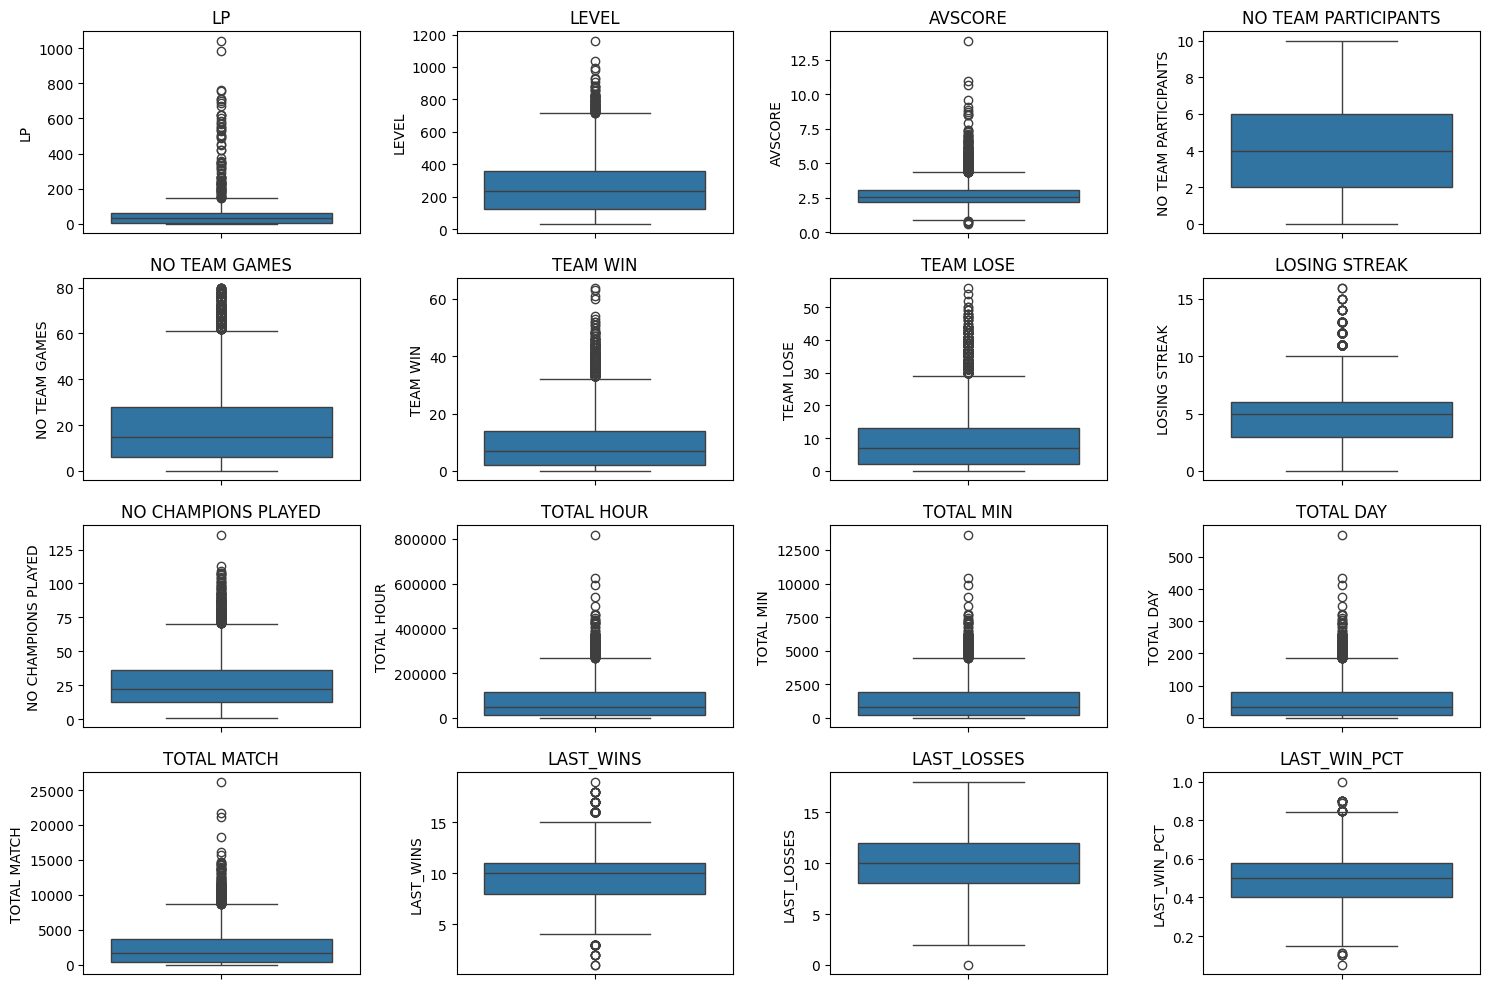

In [19]:
#Visualize Outliers with Boxplots (on a sample to avoid memory issues)
sample_size = 10000  # Sample 10,000 rows for visualization
df_sample = dfEncoded[numeric_cols].sample(n=sample_size, random_state=42)

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df_sample[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [20]:
#Summarize Outliers
outlier_summary = {}
for col in numeric_cols:
    outliers_iqr, lower_bound, upper_bound = detect_outliers_iqr(dfEncoded, col)
    outliers_zscore = detect_outliers_zscore(dfEncoded, col)
    outlier_summary[col] = {
        'IQR Outliers': len(outliers_iqr),
        'IQR Lower Bound': lower_bound,
        'IQR Upper Bound': upper_bound,
        'Z-Score Outliers': len(outliers_zscore)
    }

print("Outlier Summary:")
for col, summary in outlier_summary.items():
    print(f"{col}:")
    print(f"  IQR Outliers: {summary['IQR Outliers']} (Lower: {summary['IQR Lower Bound']:.2f}, Upper: {summary['IQR Upper Bound']:.2f})")
    print(f"  Z-Score Outliers: {summary['Z-Score Outliers']}")

Outlier Summary:
LP:
  IQR Outliers: 1698 (Lower: -80.50, Upper: 147.50)
  Z-Score Outliers: 1568
LEVEL:
  IQR Outliers: 2312 (Lower: -232.50, Upper: 715.50)
  Z-Score Outliers: 1961
AVSCORE:
  IQR Outliers: 9437 (Lower: 0.86, Upper: 4.41)
  Z-Score Outliers: 3738
NO TEAM PARTICIPANTS:
  IQR Outliers: 0 (Lower: -4.00, Upper: 12.00)
  Z-Score Outliers: 0
NO TEAM GAMES:
  IQR Outliers: 7924 (Lower: -27.00, Upper: 61.00)
  Z-Score Outliers: 2561
TEAM WIN:
  IQR Outliers: 9872 (Lower: -16.00, Upper: 32.00)
  Z-Score Outliers: 4016
TEAM LOSE:
  IQR Outliers: 7840 (Lower: -16.00, Upper: 32.00)
  Z-Score Outliers: 4077
LOSING STREAK:
  IQR Outliers: 7115 (Lower: -1.50, Upper: 10.50)
  Z-Score Outliers: 1408
NO CHAMPIONS PLAYED:
  IQR Outliers: 7291 (Lower: -21.50, Upper: 70.50)
  Z-Score Outliers: 3567
TOTAL HOUR:
  IQR Outliers: 6344 (Lower: -139138.38, Upper: 265982.62)
  Z-Score Outliers: 3778
TOTAL MIN:
  IQR Outliers: 6340 (Lower: -2319.00, Upper: 4433.00)
  Z-Score Outliers: 3779
TOTAL 

In [21]:
#Handle Outliers by Capping
df_outlier_handled = dfEncoded.copy()
for col in numeric_cols:
    Q1 = dfEncoded[col].quantile(0.25)
    Q3 = dfEncoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_outlier_handled[col] = dfEncoded[col].clip(lower=lower_bound, upper=upper_bound)

#Verify Outliers After Capping
outlier_summary_after = {}
for col in numeric_cols:
    outliers_iqr, lower_bound, upper_bound = detect_outliers_iqr(df_outlier_handled, col)
    outlier_summary_after[col] = len(outliers_iqr)

print("\nOutliers After Capping:")
for col, count in outlier_summary_after.items():
    print(f"{col}: {count} outliers remaining")


Outliers After Capping:
LP: 0 outliers remaining
LEVEL: 0 outliers remaining
AVSCORE: 0 outliers remaining
NO TEAM PARTICIPANTS: 0 outliers remaining
NO TEAM GAMES: 0 outliers remaining
TEAM WIN: 0 outliers remaining
TEAM LOSE: 0 outliers remaining
LOSING STREAK: 0 outliers remaining
NO CHAMPIONS PLAYED: 0 outliers remaining
TOTAL HOUR: 0 outliers remaining
TOTAL MIN: 0 outliers remaining
TOTAL DAY: 0 outliers remaining
TOTAL MATCH: 0 outliers remaining
LAST_WINS: 0 outliers remaining
LAST_LOSSES: 0 outliers remaining
LAST_WIN_PCT: 0 outliers remaining


In [22]:
#Check Data Integrity
print("\nMissing Values After Outlier Handling:")
print(df_outlier_handled.isnull().sum())

print("\nDataset Shape After Outlier Handling:", df_outlier_handled.shape)
print("\nFirst 5 Rows of Handled Dataset:")
print(df_outlier_handled.head())


Missing Values After Outlier Handling:
LP                       478
LEVEL                    478
AVSCORE                  478
NO TEAM PARTICIPANTS     478
NO TEAM GAMES            478
TEAM WIN                 478
TEAM LOSE                478
LOSING STREAK            478
NO CHAMPIONS PLAYED      478
TOTAL HOUR               478
TOTAL MIN                478
TOTAL DAY                478
TOTAL MATCH              478
LAST_WINS                478
LAST_LOSSES              478
LAST_WIN_PCT             478
TIER_ENCODED             478
SEASON_TIER_ENCODED      478
LAST_TIER_ENCODED        478
WIN_DUMMY                478
T_POSITION_Jungle        478
T_POSITION_Mid           478
T_POSITION_Support       478
T_POSITION_Top           478
START SEASON_S2021       478
START SEASON_S2022       478
START SEASON_S2023       478
START SEASON_Season 1    478
START SEASON_Season 2    478
START SEASON_Season 3    478
START SEASON_Season 4    478
START SEASON_Season 5    478
START SEASON_Season 6    478
STA

In [23]:
#Drop rows with any NaNs
df_cleaned = df_outlier_handled.dropna()
print("\nShape after dropping NaNs:", df_cleaned.shape)
print("Missing Values in df_cleaned:")
print(df_cleaned.isnull().sum())


Shape after dropping NaNs: (294530, 41)
Missing Values in df_cleaned:
LP                       0
LEVEL                    0
AVSCORE                  0
NO TEAM PARTICIPANTS     0
NO TEAM GAMES            0
TEAM WIN                 0
TEAM LOSE                0
LOSING STREAK            0
NO CHAMPIONS PLAYED      0
TOTAL HOUR               0
TOTAL MIN                0
TOTAL DAY                0
TOTAL MATCH              0
LAST_WINS                0
LAST_LOSSES              0
LAST_WIN_PCT             0
TIER_ENCODED             0
SEASON_TIER_ENCODED      0
LAST_TIER_ENCODED        0
WIN_DUMMY                0
T_POSITION_Jungle        0
T_POSITION_Mid           0
T_POSITION_Support       0
T_POSITION_Top           0
START SEASON_S2021       0
START SEASON_S2022       0
START SEASON_S2023       0
START SEASON_Season 1    0
START SEASON_Season 2    0
START SEASON_Season 3    0
START SEASON_Season 4    0
START SEASON_Season 5    0
START SEASON_Season 6    0
START SEASON_Season 7    0
START SEASO

## Feature Scaling


In [24]:
from sklearn.preprocessing import StandardScaler
#Apply StandardScaler to all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cleaned)

#Convert scaled data back to DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=df_cleaned.columns)

In [25]:
#Verify Scaling
print("Scaled Data Statistics:")
print(X_scaled_df.describe().round(2))  #Check mean ~0, std ~1 for each column

Scaled Data Statistics:
              LP      LEVEL    AVSCORE  NO TEAM PARTICIPANTS  NO TEAM GAMES  \
count  294530.00  294530.00  294530.00             294530.00      294530.00   
mean        0.00       0.00      -0.00                 -0.00           0.00   
std         1.00       1.00       1.00                  1.00           1.00   
min        -1.15      -1.46      -2.61                 -1.36          -1.16   
25%        -1.00      -0.85      -0.70                 -0.68          -0.79   
50%        -0.19      -0.13      -0.13                  0.00          -0.19   
75%         0.77       0.67       0.57                  0.68           0.54   
max         3.43       2.96       2.48                  2.04           2.54   

        TEAM WIN  TEAM LOSE  LOSING STREAK  NO CHAMPIONS PLAYED  TOTAL HOUR  \
count  294530.00  294530.00      294530.00            294530.00   294530.00   
mean        0.00      -0.00           0.00                 0.00       -0.00   
std         1.00       1.00

In [26]:
#Check for Missing Values
print("\nMissing Values After Scaling:")
print(X_scaled_df.isnull().sum())


Missing Values After Scaling:
LP                       0
LEVEL                    0
AVSCORE                  0
NO TEAM PARTICIPANTS     0
NO TEAM GAMES            0
TEAM WIN                 0
TEAM LOSE                0
LOSING STREAK            0
NO CHAMPIONS PLAYED      0
TOTAL HOUR               0
TOTAL MIN                0
TOTAL DAY                0
TOTAL MATCH              0
LAST_WINS                0
LAST_LOSSES              0
LAST_WIN_PCT             0
TIER_ENCODED             0
SEASON_TIER_ENCODED      0
LAST_TIER_ENCODED        0
WIN_DUMMY                0
T_POSITION_Jungle        0
T_POSITION_Mid           0
T_POSITION_Support       0
T_POSITION_Top           0
START SEASON_S2021       0
START SEASON_S2022       0
START SEASON_S2023       0
START SEASON_Season 1    0
START SEASON_Season 2    0
START SEASON_Season 3    0
START SEASON_Season 4    0
START SEASON_Season 5    0
START SEASON_Season 6    0
START SEASON_Season 7    0
START SEASON_Season 8    0
START SEASON_Season 9   

In [27]:
#Display First Few Rows of Scaled Data
print("\nFirst 5 Rows of Scaled Data:")
print(X_scaled_df.head())

#Save Scaled Data for Clustering
#X_scaled is ready for clustering (numpy array format)
print("\nScaled Data Shape:", X_scaled.shape)


First 5 Rows of Scaled Data:
         LP     LEVEL   AVSCORE  NO TEAM PARTICIPANTS  NO TEAM GAMES  \
0  3.425178  1.067099  1.749076              2.044432       0.176353   
1  3.425178  1.021999  1.330759              2.044432       0.539643   
2  3.425178  1.795144  1.868390              2.044432       0.539643   
3  3.425178  2.213931 -1.447959              2.044432       0.721288   
4  3.425178  1.195956  1.215758              2.044432       0.842385   

   TEAM WIN  TEAM LOSE  LOSING STREAK  NO CHAMPIONS PLAYED  TOTAL HOUR  ...  \
0 -0.291490   0.667444       0.878215             1.069982   -0.789471  ...   
1  0.718733   0.315416      -1.127975             0.536676    0.962031  ...   
2  1.279967  -0.271296      -1.930450             0.418163    0.455442  ...   
3  0.718733   0.667444      -0.325499            -1.241010    2.113867  ...   
4  0.157498   1.488841       0.476977            -0.055886    1.345075  ...   

   START SEASON_Season 5  START SEASON_Season 6  START SEASON_

##EDA

In [28]:
#Summary Statistics
print("Summary Statistics for Numeric Features:")
numeric_cols = ['LP', 'LEVEL', 'AVSCORE', 'NO TEAM PARTICIPANTS', 'NO TEAM GAMES',
                'TEAM WIN', 'TEAM LOSE', 'LOSING STREAK', 'NO CHAMPIONS PLAYED',
                'TOTAL HOUR', 'TOTAL MIN', 'TOTAL DAY', 'TOTAL MATCH',
                'LAST_WINS', 'LAST_LOSSES', 'LAST_WIN_PCT']
print(df_cleaned[numeric_cols].describe().round(2))

Summary Statistics for Numeric Features:
              LP      LEVEL    AVSCORE  NO TEAM PARTICIPANTS  NO TEAM GAMES  \
count  294530.00  294530.00  294530.00             294530.00      294530.00   
mean       37.13     255.38       2.68                  3.99          19.09   
std        32.22     155.21       0.70                  2.94          16.52   
min         0.00      29.00       0.86                  0.00           0.00   
25%         5.00     123.00       2.19                  2.00           6.00   
50%        31.00     235.00       2.59                  4.00          16.00   
75%        62.00     360.00       3.08                  6.00          28.00   
max       147.50     715.50       4.40                 10.00          61.00   

        TEAM WIN  TEAM LOSE  LOSING STREAK  NO CHAMPIONS PLAYED  TOTAL HOUR  \
count  294530.00  294530.00      294530.00            294530.00   294530.00   
mean        9.60       9.31           4.81                25.94    72102.01   
std       

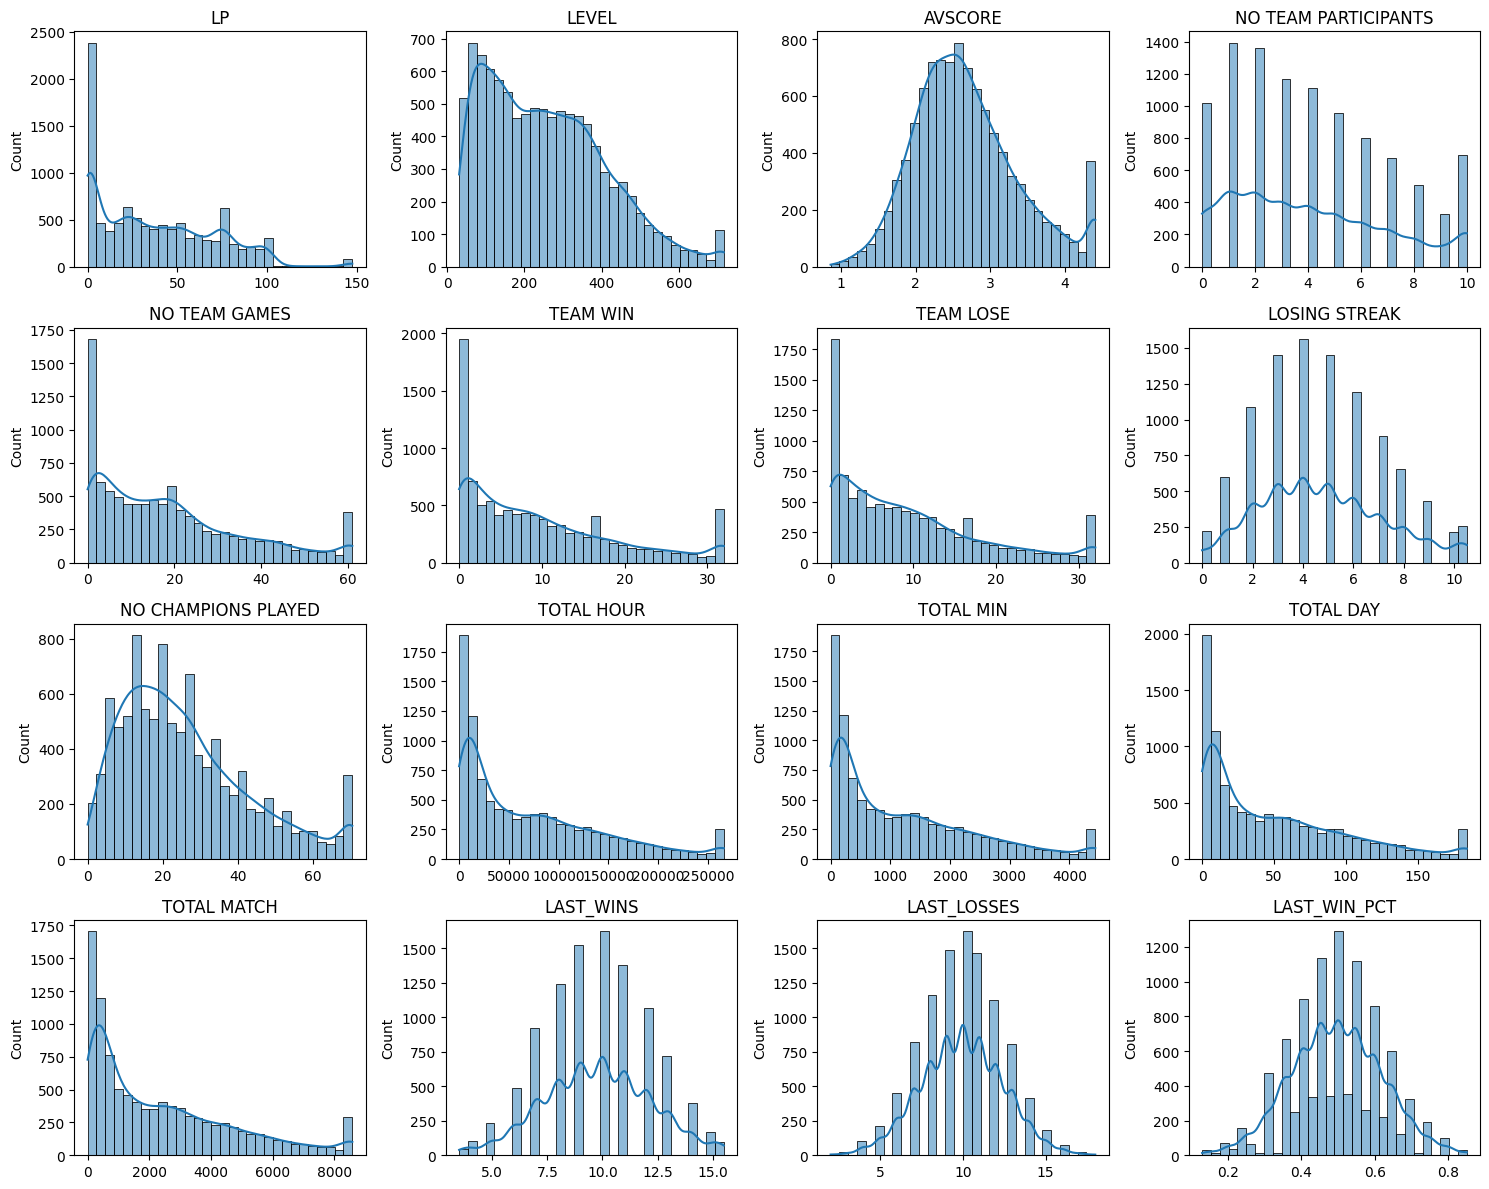

In [29]:
#Distributions
#Sample data for visualizations to avoid memory issues
sample_size = 10000
df_sample = df_cleaned.sample(n=sample_size, random_state=42)

#Histograms for Numeric Features
plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df_sample[col], bins=30, kde=True)
    plt.title(col)
    plt.xlabel('')
plt.tight_layout()
plt.show()

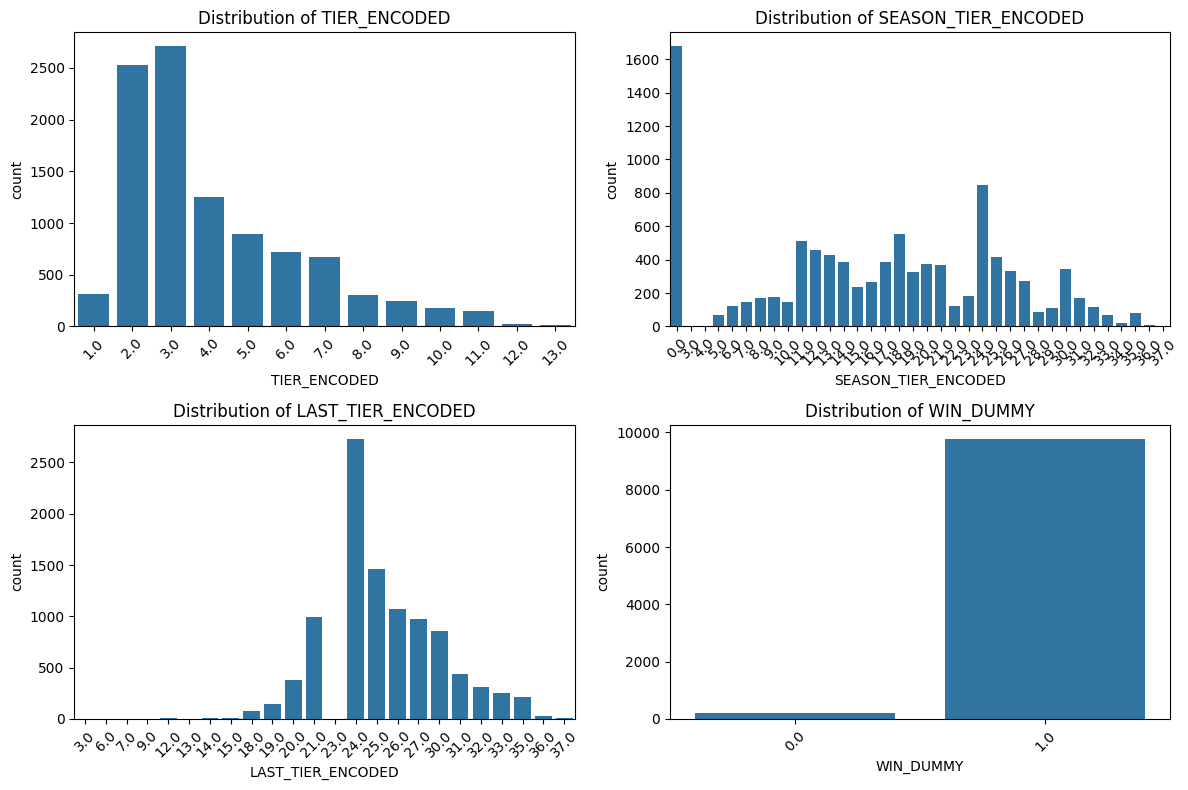

In [30]:
#Bar Plots for Categorical/Ordinal Features
categorical_cols = ['TIER_ENCODED', 'SEASON_TIER_ENCODED', 'LAST_TIER_ENCODED', 'WIN_DUMMY']
plt.figure(figsize=(12, 8))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df_sample, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

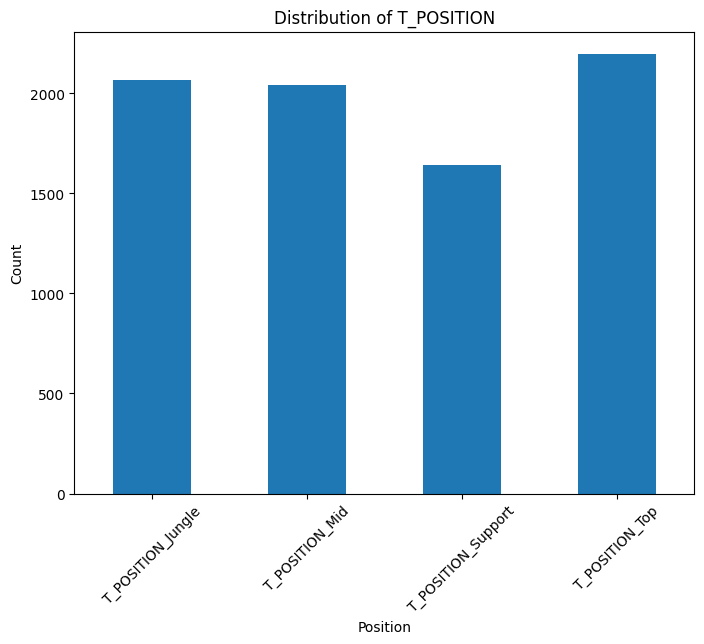

In [31]:
#Bar Plots for T_POSITION (aggregate one-hot columns)
t_position_cols = [col for col in df_outlier_handled.columns if col.startswith('T_POSITION_')]
t_position_counts = df_sample[t_position_cols].sum()
plt.figure(figsize=(8, 6))
t_position_counts.plot(kind='bar')
plt.title('Distribution of T_POSITION')
plt.xlabel('Position')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

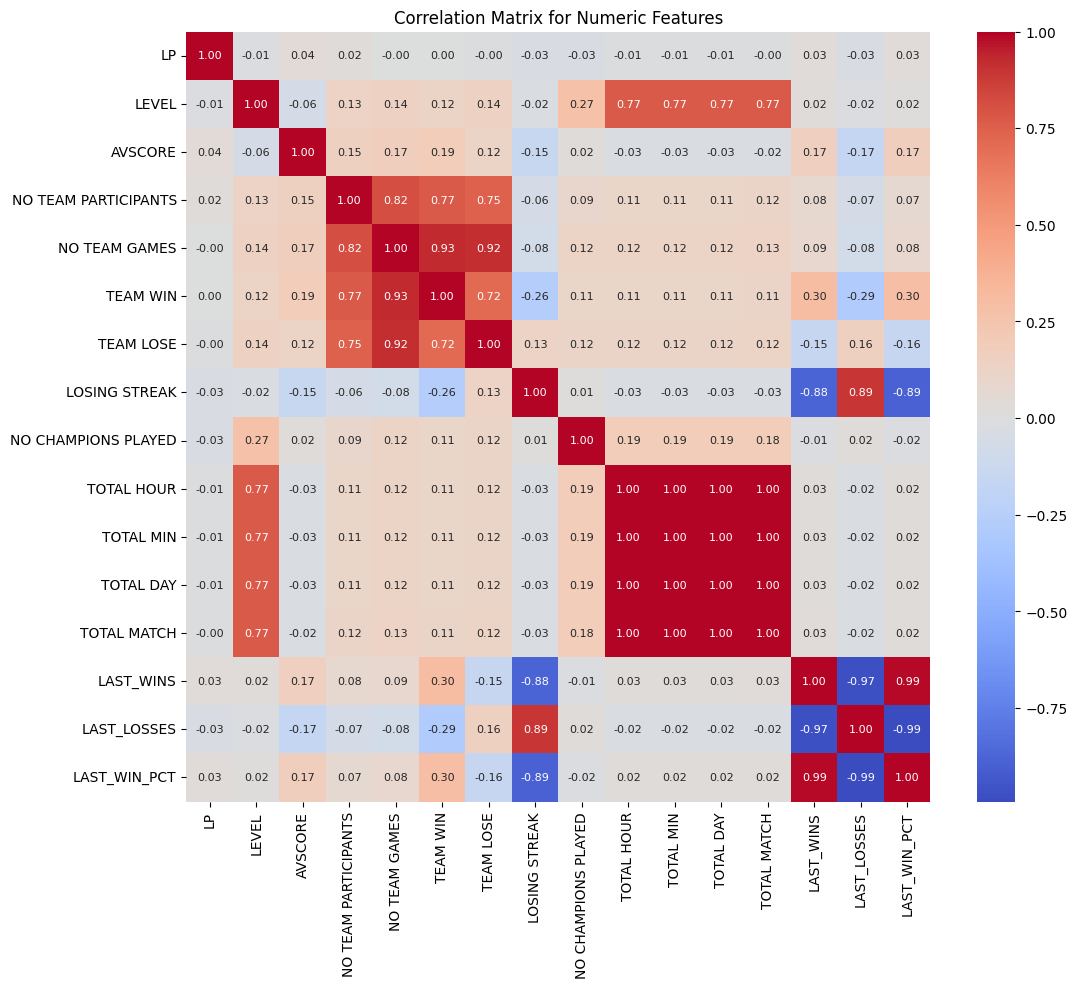

In [32]:
#Correlation Analysis
plt.figure(figsize=(12, 10))
corr = df_outlier_handled[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={'size': 8})
plt.title('Correlation Matrix for Numeric Features')
plt.show()

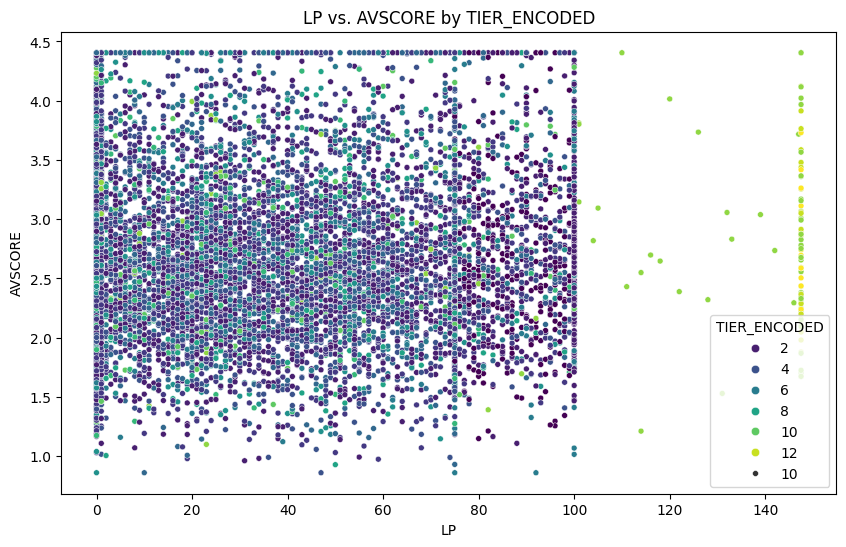

In [33]:
#Relationships
#Scatter Plot: LP vs. AVSCORE, colored by TIER_ENCODED
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x='LP', y='AVSCORE', hue='TIER_ENCODED', palette='viridis', size=10)
plt.title('LP vs. AVSCORE by TIER_ENCODED')
plt.show()

<ipython-input-34-056baa095ab8>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t_position_melted['T_POSITION'] = t_position_melted['T_POSITION'].str.replace('T_POSITION_', '')


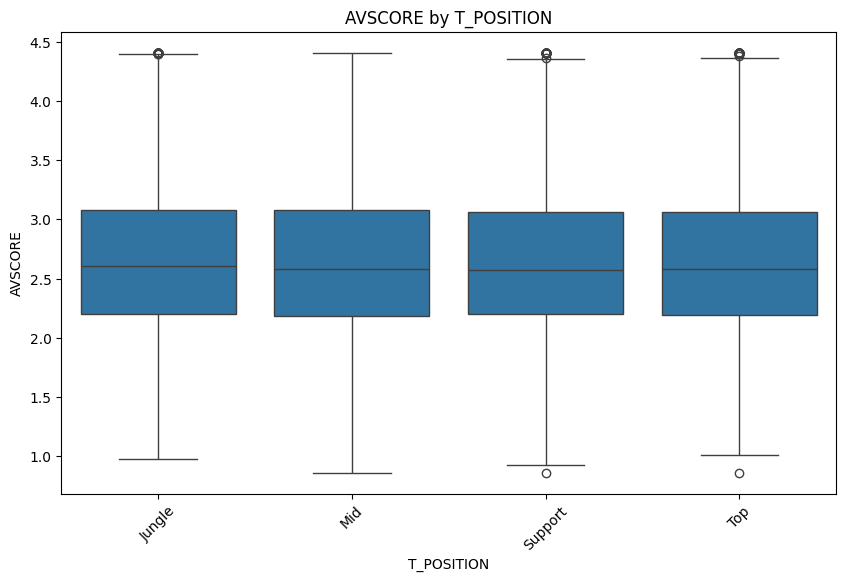

In [34]:
#Boxplot: AVSCORE by T_POSITION (using a melted DataFrame)
t_position_melted = df_sample.melt(id_vars=['AVSCORE'], value_vars=t_position_cols,
                                   var_name='T_POSITION', value_name='Present')
t_position_melted = t_position_melted[t_position_melted['Present'] == 1]
t_position_melted['T_POSITION'] = t_position_melted['T_POSITION'].str.replace('T_POSITION_', '')
plt.figure(figsize=(10, 6))
sns.boxplot(data=t_position_melted, x='T_POSITION', y='AVSCORE')
plt.title('AVSCORE by T_POSITION')
plt.xticks(rotation=45)
plt.show()

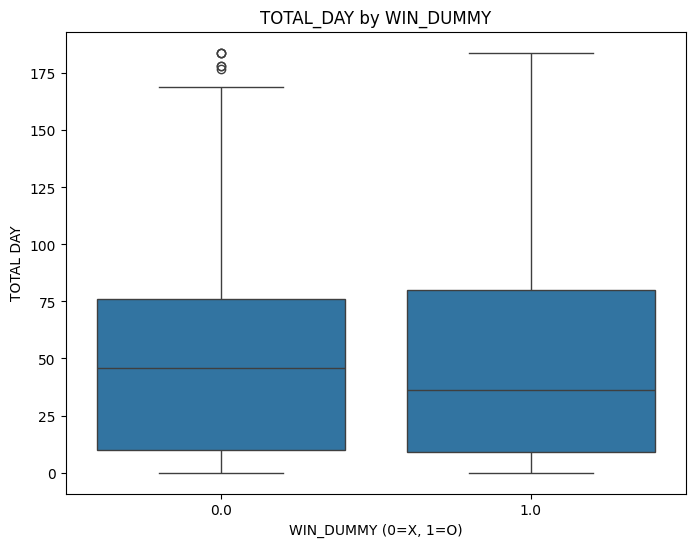

In [35]:
#Boxplot: TOTAL_DAY by WIN_DUMMY
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_sample, x='WIN_DUMMY', y='TOTAL DAY')
plt.title('TOTAL_DAY by WIN_DUMMY')
plt.xlabel('WIN_DUMMY (0=X, 1=O)')
plt.show()

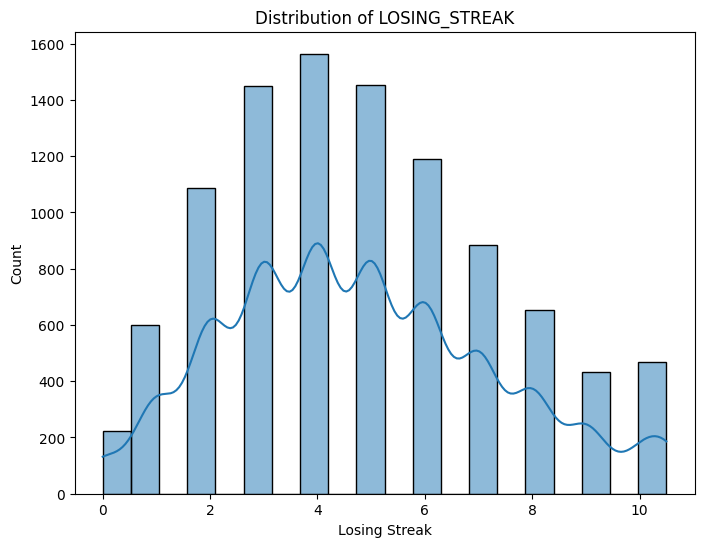

In [36]:
#Churn-Related Insights
#Distribution of LOSING_STREAK
plt.figure(figsize=(8, 6))
sns.histplot(df_sample['LOSING STREAK'], bins=20, kde=True)
plt.title('Distribution of LOSING_STREAK')
plt.xlabel('Losing Streak')
plt.show()

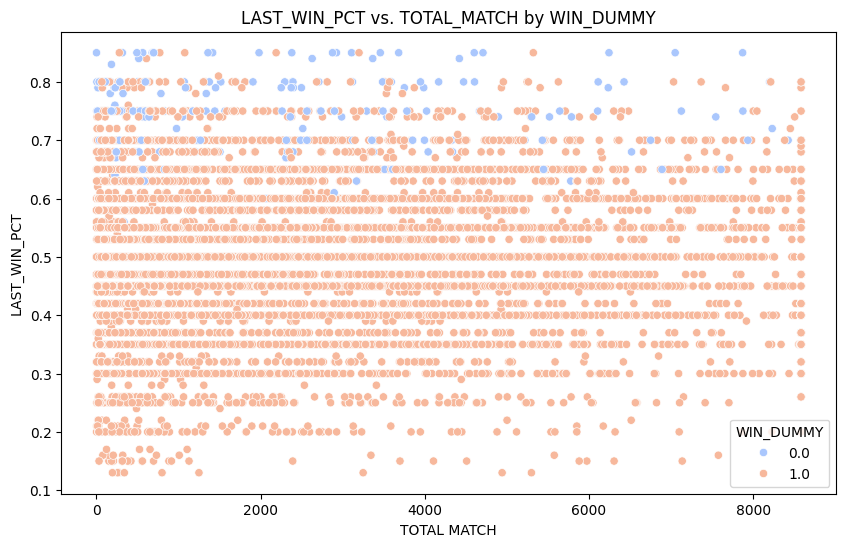

In [37]:
#LAST_WIN_PCT vs. TOTAL_MATCH
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x='TOTAL MATCH', y='LAST_WIN_PCT', hue='WIN_DUMMY', palette='coolwarm')
plt.title('LAST_WIN_PCT vs. TOTAL_MATCH by WIN_DUMMY')
plt.show()

In [38]:
#Print Key Insights
print("\nKey EDA Insights:")
print("- Numeric features like TOTAL_HOUR, TOTAL_MATCH show skewed distributions, indicating varied player engagement.")
print("- High correlations (e.g., TOTAL_HOUR vs. TOTAL_MIN) suggest potential feature redundancy.")
print("- TIER_ENCODED distribution shows concentration in certain ranks, relevant for clustering player skill levels.")
print("- AVSCORE varies by T_POSITION, suggesting role-specific performance differences.")
print("- LOSING_STREAK and LAST_WIN_PCT may indicate churn risk, with higher streaks linked to lower win percentages.")


Key EDA Insights:
- Numeric features like TOTAL_HOUR, TOTAL_MATCH show skewed distributions, indicating varied player engagement.
- High correlations (e.g., TOTAL_HOUR vs. TOTAL_MIN) suggest potential feature redundancy.
- TIER_ENCODED distribution shows concentration in certain ranks, relevant for clustering player skill levels.
- AVSCORE varies by T_POSITION, suggesting role-specific performance differences.
- LOSING_STREAK and LAST_WIN_PCT may indicate churn risk, with higher streaks linked to lower win percentages.


# Upsupervised Learning: Clustering

In [39]:
#Sample the Data to Reduce Memory Usage
sample_size = 30000  #Reduced size to fit within Colab RAM limits
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], sample_size, replace=False)
X_scaled_sample = X_scaled[sample_indices]
df_cleaned_sample = df_cleaned.iloc[sample_indices].copy()

In [40]:
#Dimensionality Reduction with PCA
pca = PCA(n_components=0.95)  # Retain 95% variance
X_reduced = pca.fit_transform(X_scaled)
print(f"Reduced to {X_reduced.shape[1]} components")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.2f}")

Reduced to 27 components
Explained variance ratio: 0.96


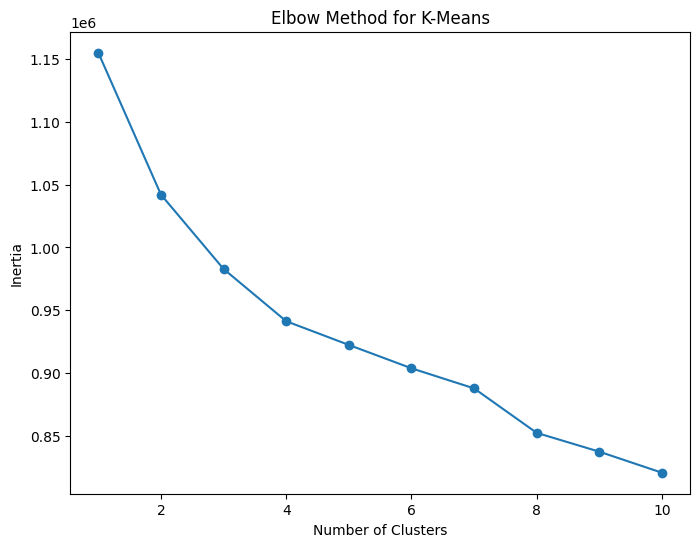

In [41]:
#Elbow Method for K-Means (on a sample to save time)
X_sample = X_reduced[np.random.choice(X_reduced.shape[0], sample_size, replace=False)]
inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_sample)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertias, marker='o')
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

The "elbow" method looks for a point where adding more clusters yields diminishing returns in reducing inertia (i.e., the curve starts to flatten).

The plot shows a steep drop from k=1 to k=3 (from 1.15e6 to 1.00e6), indicating significant improvement in clustering quality.

From k=3 to k=4, the drop is still notable (to 0.95e6), but the rate of decrease slows.

After k=4, the curve flattens more noticeably (e.g., k=5 to k=10 decreases from 0.93e6 to 0.85e6), suggesting smaller gains per additional cluster.

The elbow point appears to be around k=4, where the curve starts to flatten significantly

## K-Means

In [42]:
#Apply Clustering Algorithms
#Choose n_clusters based on elbow plot (k = 4)
n_clusters = 4

#K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(X_reduced)

## DBSCAN

In [43]:
#DBSCAN (on a smaller subset to avoid memory issues)
dbscan_sample_size = 10000  # Further reduce for DBSCAN
dbscan_indices = np.random.choice(X_reduced.shape[0], dbscan_sample_size, replace=False)
X_reduced_dbscan = X_reduced[dbscan_indices]
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels_small = dbscan.fit_predict(X_reduced_dbscan)

#Extrapolate DBSCAN labels (approximation)
dbscan_labels = np.full(X_reduced.shape[0], -1)  #Default to noise
dbscan_labels[dbscan_indices] = dbscan_labels_small

## MiniBatchKMeans Clustering

In [44]:
#MiniBatchKMeans Clustering
from sklearn.cluster import MiniBatchKMeans
minibatch_kmeans = MiniBatchKMeans(n_clusters=n_clusters, batch_size=100, random_state=42)
minibatch_kmeans_labels = minibatch_kmeans.fit_predict(X_reduced)

In [45]:
gc.collect()

32470

## Visualizing

In [46]:
#Evaluate Clusters
print("\nClustering Evaluation:")
print("Silhouette Score (K-Means):", silhouette_score(X_reduced, kmeans_labels))
print("Silhouette Score (MiniBatchKMeans):", silhouette_score(X_reduced, minibatch_kmeans_labels))
if len(np.unique(dbscan_labels)) > 1:
    print("Silhouette Score (DBSCAN):", silhouette_score(X_reduced, dbscan_labels))
print("DBSCAN Noise Points:", sum(dbscan_labels == -1))


Clustering Evaluation:
Silhouette Score (K-Means): 0.07236151271436334
Silhouette Score (MiniBatchKMeans): 0.07313625255242366
DBSCAN Noise Points: 294530


Shape of X_reduced_plot: (5000, 27)
Shape of kmeans_labels_plot: (5000,)
Shape of dbscan_labels_plot: (5000,)
Shape of minibatch_kmeans_labels_plot: (5000,)
Shape of X_pca: (5000, 2)
2D PCA Explained Variance Ratio: 0.24
Shape of X_pca[:, 0]: (5000,)
Shape of X_pca[:, 1]: (5000,)


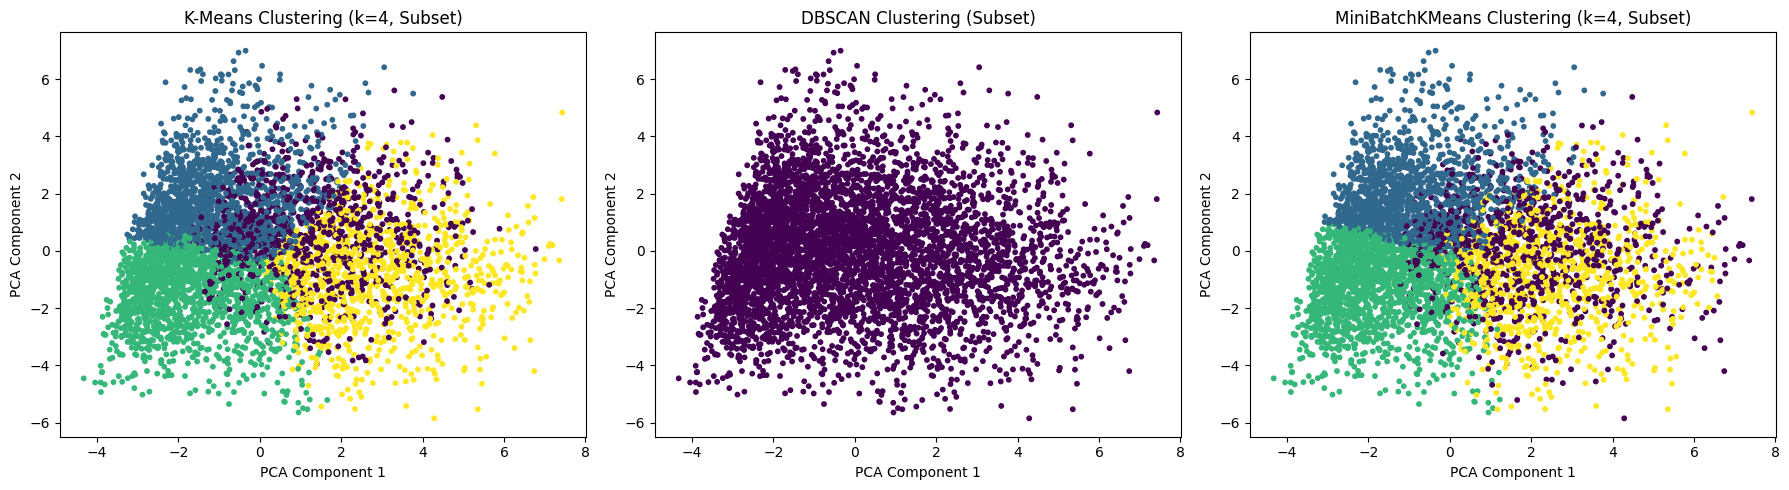

In [47]:
visualization_size = 5000  # Reduce points for plotting
plot_indices = np.random.choice(X_reduced.shape[0], visualization_size, replace=False)
X_reduced_plot = X_reduced[plot_indices]
kmeans_labels_plot = kmeans_labels[plot_indices]
dbscan_labels_plot = dbscan_labels[plot_indices]
minibatch_kmeans_labels_plot = minibatch_kmeans_labels[plot_indices]

# Verify shapes before PCA
print("Shape of X_reduced_plot:", X_reduced_plot.shape)
print("Shape of kmeans_labels_plot:", kmeans_labels_plot.shape)
print("Shape of dbscan_labels_plot:", dbscan_labels_plot.shape)
print("Shape of minibatch_kmeans_labels_plot:", minibatch_kmeans_labels_plot.shape)

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_reduced_plot)
print("Shape of X_pca:", X_pca.shape)
print(f"2D PCA Explained Variance Ratio: {pca_2d.explained_variance_ratio_.sum():.2f}")

# Verify shapes before plotting
print("Shape of X_pca[:, 0]:", X_pca[:, 0].shape)
print("Shape of X_pca[:, 1]:", X_pca[:, 1].shape)

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels_plot, cmap='viridis', s=10)
plt.title('K-Means Clustering (k=4, Subset)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels_plot, cmap='viridis', s=10)
plt.title('DBSCAN Clustering (Subset)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=minibatch_kmeans_labels_plot, cmap='viridis', s=10)
plt.title('MiniBatchKMeans Clustering (k=4, Subset)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.tight_layout()
plt.show()

## Cluster Interpretation

In [50]:
# Cluster Interpretation
# Add cluster labels to df_cleaned for analysis using .loc
df_cleaned.loc[:, 'KMeans_Cluster'] = kmeans_labels
df_cleaned.loc[:, 'DBSCAN_Cluster'] = dbscan_labels
df_cleaned.loc[:, 'MiniBatchKMeans_Cluster'] = minibatch_kmeans_labels

In [51]:
#Numeric columns for interpretation
numeric_cols = ['LP', 'LEVEL', 'AVSCORE', 'LAST_WINS', 'LAST_LOSSES', 'LAST_WIN_PCT']
numeric_cols = [col for col in numeric_cols if col in df_cleaned.columns]
print("\nK-Means Cluster Means for Numeric Features:")
cluster_means = df_cleaned.groupby('KMeans_Cluster')[numeric_cols].mean().round(2)
print(cluster_means)


K-Means Cluster Means for Numeric Features:
                   LP   LEVEL  AVSCORE  LAST_WINS  LAST_LOSSES  LAST_WIN_PCT
KMeans_Cluster                                                              
0               36.82  278.80     2.85      10.10         9.65          0.51
1               39.14  183.96     2.80      11.80         7.87          0.60
2               35.69  181.73     2.50       7.56        12.14          0.38
3               36.68  435.65     2.60       9.74         9.98          0.49


In [52]:
#T_POSITION distribution
t_position_cols = [col for col in df_cleaned.columns if col.startswith('T_POSITION_')]
if t_position_cols:
    print("\nK-Means Cluster T_POSITION Distribution:")
    t_position_dist = df_cleaned.groupby('KMeans_Cluster')[t_position_cols].mean().round(2)
    print(t_position_dist)


K-Means Cluster T_POSITION Distribution:
                T_POSITION_Jungle  T_POSITION_Mid  T_POSITION_Support  \
KMeans_Cluster                                                          
0                             0.2            0.21                0.15   
1                             0.2            0.20                0.16   
2                             0.2            0.20                0.16   
3                             0.2            0.21                0.16   

                T_POSITION_Top  
KMeans_Cluster                  
0                         0.23  
1                         0.23  
2                         0.23  
3                         0.23  


In [53]:
#Additional Insights: WIN_DUMMY and TIER_ENCODED
if 'WIN_DUMMY' in df_cleaned.columns:
    print("\nK-Means Cluster WIN_DUMMY Distribution:")
    win_dummy_dist = df_cleaned.groupby('KMeans_Cluster')['WIN_DUMMY'].mean().round(2)
    print(win_dummy_dist)

if 'TIER_ENCODED' in df_cleaned.columns:
    print("\nK-Means Cluster TIER_ENCODED Means:")
    tier_encoded_means = df_cleaned.groupby('KMeans_Cluster')['TIER_ENCODED'].mean().round(2)
    print(tier_encoded_means)


K-Means Cluster WIN_DUMMY Distribution:
KMeans_Cluster
0    0.99
1    0.94
2    1.00
3    0.99
Name: WIN_DUMMY, dtype: float64

K-Means Cluster TIER_ENCODED Means:
KMeans_Cluster
0    3.60
1    4.27
2    4.01
3    4.31
Name: TIER_ENCODED, dtype: float64


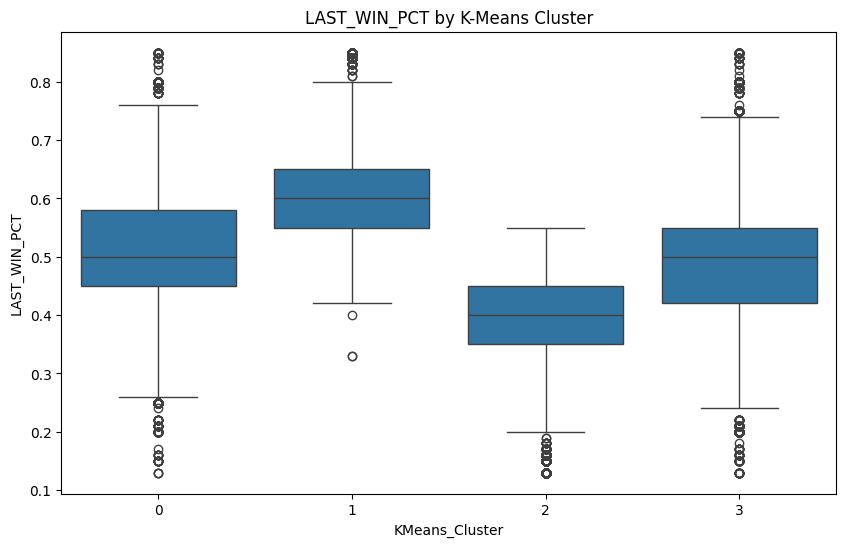

In [54]:
#Additional Visualization: LAST_WIN_PCT by Cluster
if 'LAST_WIN_PCT' in df_cleaned.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_cleaned, x='KMeans_Cluster', y='LAST_WIN_PCT')
    plt.title('LAST_WIN_PCT by K-Means Cluster')
    plt.show()

In [55]:
#Key Insights
print("\nKey Clustering Insights:")
print("- K-Means clusters (k=4) may separate players into distinct segments (e.g., skilled vs. casual vs. churn-risk).")
print("- High TIER_ENCODED and LP clusters likely represent skilled players.")
print("- Low LAST_WIN_PCT or WIN_DUMMY=0 clusters may indicate churn risk.")
print("- DBSCAN noise points could highlight outliers (e.g., extreme LAST_WIN_PCT).")
print("- Hierarchical clusters may reveal nested segments within skill levels.")


Key Clustering Insights:
- K-Means clusters (k=4) may separate players into distinct segments (e.g., skilled vs. casual vs. churn-risk).
- High TIER_ENCODED and LP clusters likely represent skilled players.
- Low LAST_WIN_PCT or WIN_DUMMY=0 clusters may indicate churn risk.
- DBSCAN noise points could highlight outliers (e.g., extreme LAST_WIN_PCT).
- Hierarchical clusters may reveal nested segments within skill levels.


In [56]:
#Save the sampled dataset with cluster labels
df_cleaned_sample.to_csv('lol_clustered_data_sample.csv', index=False)
print("Sampled clustered dataset saved as 'lol_clustered_data_sample.csv'")

Sampled clustered dataset saved as 'lol_clustered_data_sample.csv'
